In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
from pathlib import Path
import numpy as np
import pandas as pd

from aind_hcr_data_loader.codeocean_utils import (
    MouseRecord,
    attach_mouse_record_to_workstation,
    print_attach_results,
)
from aind_hcr_data_loader.hcr_dataset import create_hcr_dataset_from_schema
from aind_hcr_data_loader.pairwise_dataset import create_pairwise_unmixing_dataset

import aind_hcr_qc.viz as viz
from aind_hcr_qc.viz.intergrated_datasets import plot_intensity_violins
from aind_hcr_qc.viz.single_cell_unmixing import (
    plot_spot_projection,
    plot_spot_measure_distributions,
    plot_cell_qc,
    plot_spot_nn_distances,
    plot_adjacent_channel_scatter,
)


import aind_hcr_qc.viz.single_cell_unmixing as scu

from aind_hcr_qc.viz.spot_detection import (
    annotate_spots_df,
    plot_removal_metric_distributions,
)
from aind_hcr_qc.constants import Z1_CHANNEL_CMAP_VIBRANT

In [2]:
# notebook setup
data_dir = Path('/root/capsule/data')
bucket_name = "aind-open-data"

# notebook configuration
%matplotlib inline
%load_ext autoreload
%autoreload 2


In [4]:
pairwise_asset_name

'HCR_767022_pairwise-unmixing_2026-03-08_12-00-00'

In [3]:
# ── configuration ────────────────────────────────────────────────────────────
MOUSE_ID = "767022"
  # use a mouse that has a pairwise_unmixing derived asset
CATALOG_PATH = Path(f"/src/ophys-mfish-dataset-catalog/mice/{MOUSE_ID}.json")
DATA_DIR     = Path("/root/capsule/data")
OUTPUT_DIR = Path(f"/root/capsule/scratch/single_cell_unmixing/{MOUSE_ID}")

# ── attach & load ────────────────────────────────────────────────────────────
record  = MouseRecord.from_json_file(CATALOG_PATH)
results = attach_mouse_record_to_workstation(record)
print_attach_results(results)

dataset = create_hcr_dataset_from_schema(CATALOG_PATH, DATA_DIR)
dataset.summary()

# ── pairwise unmixing (optional) ─────────────────────────────────────────────
# The pairwise asset name lives in derived_assets["pairwise_unmixing"] when present.
pairwise_asset_name = record.derived_assets.get("pairwise_unmixing")

if pairwise_asset_name is not None:
    pairwise_asset_path = DATA_DIR / pairwise_asset_name
    # Some pipeline outputs nest data under a "pairwise_unmixing" subfolder
    if (pairwise_asset_path / "pairwise_unmixing").exists():
        pairwise_asset_path = pairwise_asset_path / "pairwise_unmixing"
    pw_ds = create_pairwise_unmixing_dataset(
        mouse_id=MOUSE_ID,
        pairwise_asset_path=pairwise_asset_path,
        source_dataset=dataset,   # delegates zarr / segmentation calls
    )
    pw_ds.summary()
else:
    print("No pairwise_unmixing asset found in catalog record — skipping.")


  [rounds.R1]  HCR_767022_2025-07-03_13-00-00_processed_2025-07-18_09-27-44  →  ✓ attached
  [rounds.R2]  HCR_767022_2025-07-11_13-00-00_processed_2025-07-21_17-35-18  →  ✓ attached
  [rounds.R3]  HCR_767022_2025-07-18_13-00-00_processed_2025-07-21_17-35-38  →  ✓ attached
  [rounds.R4]  HCR_767022_2025-07-25_13-00-00_processed_2025-07-26_19-56-19  →  ✓ attached
  [rounds.R5]  HCR_767022_2025-07-31_13-00-00_processed_2025-08-01_16-55-47  →  ✓ attached
  [derived_assets.roi_shape_metrics]  HCR_767022_2025-07-03_13-00-00_roi-shape-metrics  →  ✓ attached
  [derived_assets.cell_typing]  HCR_767022_cell-typing_2026-03-08_12-00-00  →  ✓ attached
  [derived_assets.pairwise_unmixing]  HCR_767022_pairwise-unmixing_2026-04-15_21-20-26  →  ✓ attached
[DEBUG get_spot_files] key=R1 round_num=1
[DEBUG get_spot_files] folder_path=/root/capsule/data/HCR_767022_2025-07-03_13-00-00_processed_2025-07-18_09-27-44/image_spot_spectral_unmixing exists=False
[DEBUG get_spot_files] unmixed_spots=None  mixed_spo

/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:2500: UserWarning: [get_spot_files] R4: no unmixed_spots_R4*.pkl found; falling back to R-1 file: unmixed_spots_R-1_minDist_3.pkl
  _warnings.warn(
/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:2509: UserWarning: [get_spot_files] R4: no mixed_spots_R4.pkl found; falling back to R-1 file: mixed_spots_R-1.pkl
  _warnings.warn(


mouse_id: 767022
Could not load metadata for mouse 767022
Cell-typing asset attached: CellTypingFiles(asset='HCR_767022_cell-typing_2026-03-08_12-00-00', basic_results=✓, h5ad=✓)
HCR Dataset Summary
Mouse ID: 767022
Rounds: R1, R2, R3, R4, R5

Channels by round:
  R1: 405, 488, 514, 594
  R2: 405, 514, 561, 638, 594, 488
  R3: 594, 514, 405, 561, 488, 638
  R4: 488, 594, 514, 405, 561, 638
  R5: 514, 594, 561, 488, 638, 405

Cell-typing: ✓  (CellTypingFiles(asset='HCR_767022_cell-typing_2026-03-08_12-00-00', basic_results=✓, h5ad=✓))

Segmentation files by round:
  R1: resolutions 0, 2, centroids: ✓
  R2: resolutions 0, 2, centroids: ✗
  R3: resolutions 0, 2, centroids: ✗
  R4: resolutions 0, 2, centroids: ✗
  R5: resolutions 0, 2, centroids: ✗

Spot detection files by round:
  R2: channels 561, 594, 638, 488, 514
    561: spots ✓, stats files: 5
    594: spots ✓, stats files: 5
    638: spots ✓, stats files: 5
    488: spots ✓, stats files: 5
    514: spots ✓, stats files: 5
  R3: cha

In [4]:

# channel display order and fixed colors
CHAN_ORDER  = ["488", "514", "561", "594", "638"]
CHAN_COLORS = {k: v for k, v in Z1_CHANNEL_CMAP_VIBRANT.items() if k in CHAN_ORDER}

# ── load spots (both tables) for this cell ───────────────────────────────────
mixed_all   = pw_ds.load_all_rounds_spots_mp(table_type="mixed_spots",   remove_fg_bg_cols=True)
unmixed_all = pw_ds.load_all_rounds_spots_mp(table_type="unmixed_spots",  remove_fg_bg_cols=True)

Loading mixed_spots for round R2: 767022_R2
Loading mixed_spots for round R3: 767022_R3
Loading mixed_spots for round R4: 767022_R4
Loading mixed_spots for round R5: 767022_R5




Number of mixed_spots: 3.238e+07
Loading unmixed_spots for round R3: 767022_R3
Loading unmixed_spots for round R2: 767022_R2
Loading unmixed_spots for round R4: 767022_R4



Loading unmixed_spots for round R5: 767022_R5

Number of unmixed_spots: 2.298e+07


In [5]:
# ── Annotate once (valid_spot-aware) ──────────────────────────────────────────
mixed_ann, unmixed_ann = scu.annotate_spots_with_valid(mixed_all, unmixed_all)

In [5]:
# ── Run exemplar selection & plotting for every round ─────────────────────────

rounds = sorted(mixed_all["round"].unique())
round_summaries = {}    # round_key → summary DataFrame
#round_exemplars = {}    # round_key → (exemplar_ids, slot_assignments)

for rk in rounds:
    print(f"\n{'═' * 60}")
    print(f"  {rk}")
    print(f"{'═' * 60}")

    # 1. build summary
    summary = scu.build_round_cell_summary(mixed_all, unmixed_all, rk)
    round_summaries[rk] = summary

#     print(f"  Cells: {len(summary)}")
#     print(f"  Category counts:\n{summary['category'].value_counts().to_string()}")

#     # 2. select exemplars
#     ex_ids, slots, all_slots = select_round_exemplars(summary)
#     round_exemplars[rk] = (ex_ids, slots)

#     print(f"\n  Selected {len(ex_ids)} exemplars covering "
#           f"{len(all_slots) - len(all_slots - set().union(*slots.values()) if slots else all_slots)}"
#           f"/{len(all_slots)} slots")

#     # 3. print table
#     print_exemplar_table(summary, ex_ids, slots)

#     # 4. plot
#     plot_round_exemplar_overview(summary, ex_ids, slots, rk)


════════════════════════════════════════════════════════════
  R2
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  R3
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  R4
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
  R5
════════════════════════════════════════════════════════════


In [7]:
ADJACENT_PAIRS = [("488", "514"), ("514", "561"), ("561", "594"), ("594", "638")]

In [6]:
ch ='594'
cid = 66265
rk = "R2"


mx_rnd = mixed_ann[mixed_ann["round"] == rk]
um_rnd = unmixed_ann[unmixed_ann["round"] == rk]

row = summary[summary["cell_id"] == cid].iloc[0]
n_surv = int(row.get(f"n_unmixed_{ch}", 0))
rr = row.get(f"removal_rate_{ch}", 0)
print(f"\n  ▸ Ch {ch} retained signal — cell {cid}  "
        f"({n_surv} survivors, {rr:.1%} removal)")

m_cell = mx_rnd[mx_rnd["cell_id"] == cid]
u_cell = um_rnd[um_rnd["cell_id"] == cid]

plot_cell_qc(
    m_cell, u_cell, cell_id=cid, round_key=rk,
    chan_order=CHAN_ORDER, chan_colors=CHAN_COLORS,
    dataset=dataset,
    spots_df=u_cell,
    scatter_pairs=ADJACENT_PAIRS + [("488", "594")]
)
plt.show()

NameError: name 'mixed_ann' is not defined


  ▸ Ch 594 retained signal — cell 1629  (4 survivors, 90.0% removal)


/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:464: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/zarr/core/metadata/v2.py:190: ZarrUserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a JSON document) instead of an empty list of filters.
  warnings.warn(msg, ZarrUserWarning, stacklevel=1)



1-NN cross-channel distance summary  ((x×y×z, pixels)):
     Direction      n    median      mean       std       min       max
     488 → 514     18    76.537    72.097    16.842    39.925    92.363
     514 → 488     10   237.411   221.462   118.428    39.925   382.030
     514 → 561     10    32.339    38.755    26.383    10.954   104.728
     561 → 514     32    86.924   109.471    83.464    10.954   340.068
     561 → 594     32   108.184   118.270    74.870    19.339   279.659
     594 → 561      3    29.479    27.353     5.871    19.339    33.242
     594 → 638      3    82.879    76.615    48.064    14.866   132.098
     638 → 594      4   112.447   120.440    83.366    14.866   242.002


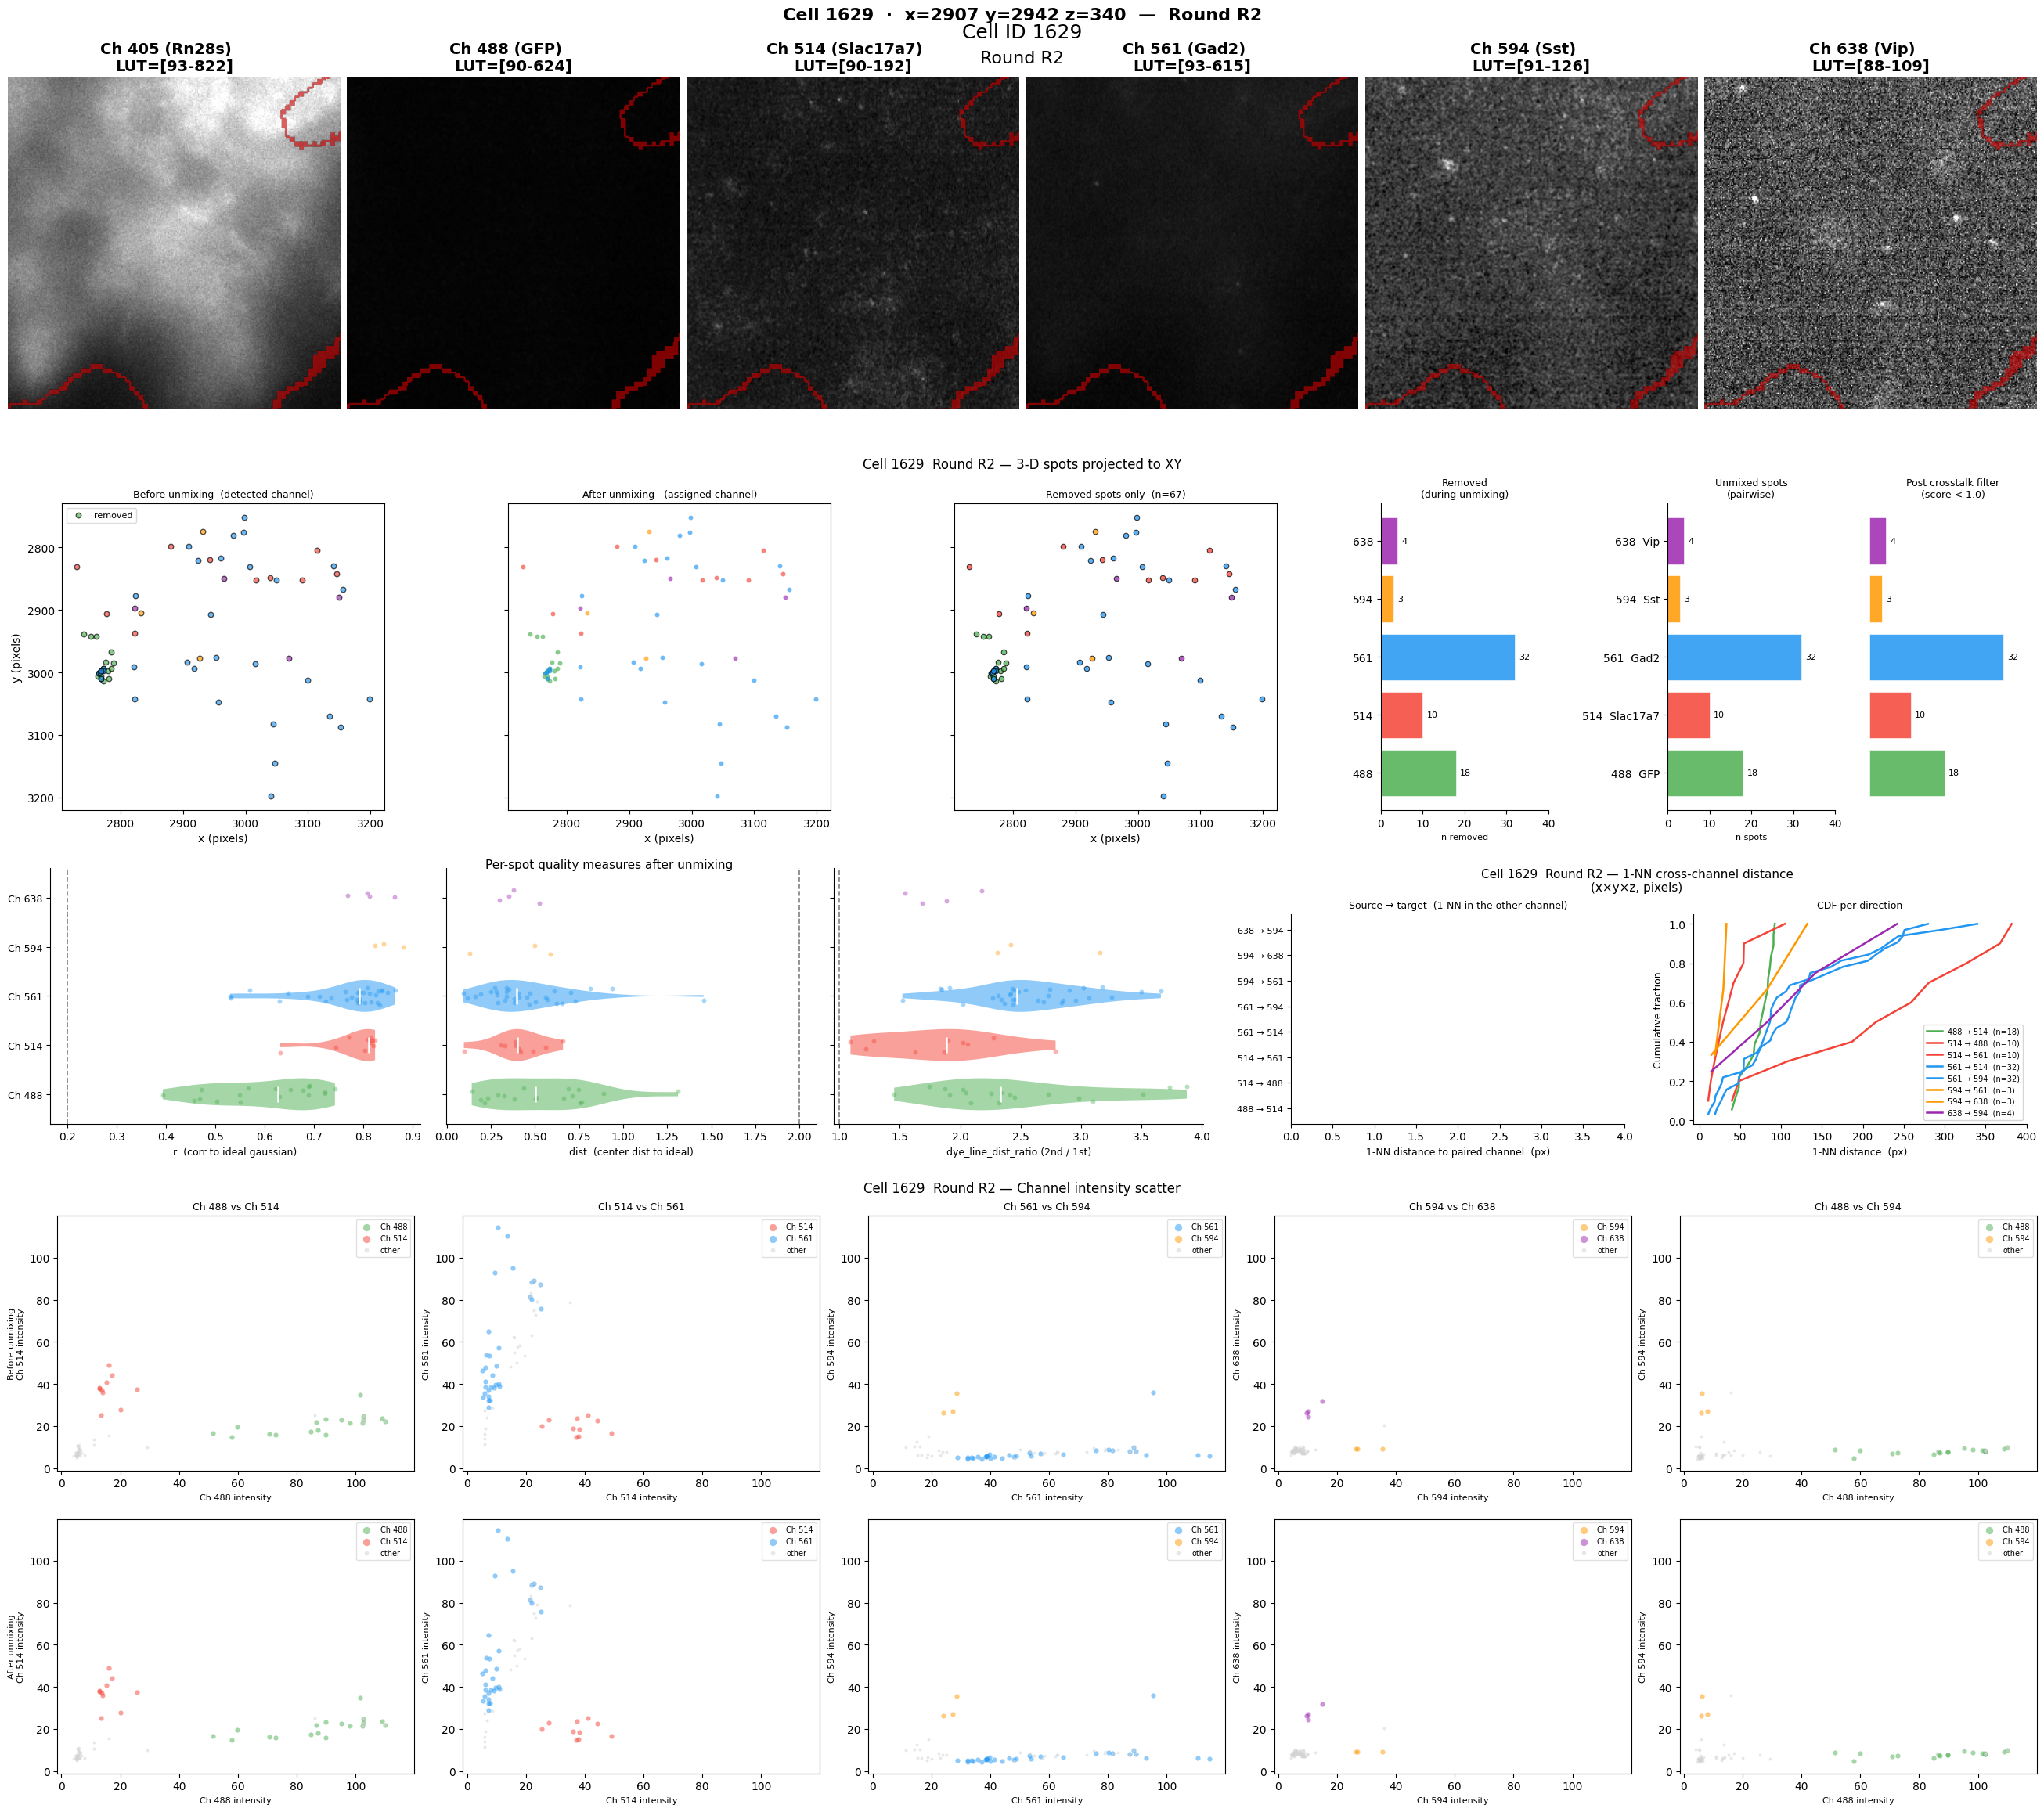

In [10]:
ch ='594'
cid = 1629
rk = "R2"


mx_rnd = mixed_ann[mixed_ann["round"] == rk]
um_rnd = unmixed_ann[unmixed_ann["round"] == rk]

row = summary[summary["cell_id"] == cid].iloc[0]
n_surv = int(row.get(f"n_unmixed_{ch}", 0))
rr = row.get(f"removal_rate_{ch}", 0)
print(f"\n  ▸ Ch {ch} retained signal — cell {cid}  "
        f"({n_surv} survivors, {rr:.1%} removal)")

m_cell = mx_rnd[mx_rnd["cell_id"] == cid]
u_cell = um_rnd[um_rnd["cell_id"] == cid]

plot_cell_qc(
    m_cell, u_cell, cell_id=cid, round_key=rk,
    chan_order=CHAN_ORDER, chan_colors=CHAN_COLORS,
    dataset=dataset,
    spots_df=u_cell,
    scatter_pairs=ADJACENT_PAIRS + [("488", "594")]
)
plt.show()

In [ ]:
plot_cell_qc( _mx, _um, cell_id=_test_cid, round_key=_test_rk, chan_order=CHAN_ORDER, spots_df=_um,chan_colors=CHAN_COLORS, dataset=dataset, scatter_pairs=ADJACENT_PAIRS + [("488", "561")])


In [14]:
# ── Run focused exemplar selection & detail plots per round ───────────────────

focused_exemplars = {}  # round_key → (retained, pair_loss)

for rk in rounds:  # just do the last round for brevity
    summary = round_summaries[rk]
    retained, pair_loss = scu.select_focused_exemplars(summary)
    focused_exemplars[rk] = (retained, pair_loss)

    print(f"\n{'═' * 70}")
    print(f"  {rk}")
    print(f"{'═' * 70}")

    # # ── filter round data ────────────────────────────────────────────────────
    # mx_rnd = mixed_ann[mixed_ann["round"] == rk]
    # um_rnd = unmixed_ann[unmixed_ann["round"] == rk]

    # # ── retained signal exemplars ────────────────────────────────────────────
    # for ch, cid in retained.items():
    #     row = summary[summary["cell_id"] == cid].iloc[0]
    #     n_surv = int(row.get(f"n_unmixed_{ch}", 0))
    #     rr = row.get(f"removal_rate_{ch}", 0)
    #     print(f"\n  ▸ Ch {ch} retained signal — cell {cid}  "
    #           f"({n_surv} survivors, {rr:.1%} removal)")

    #     m_cell = mx_rnd[mx_rnd["cell_id"] == cid]
    #     u_cell = um_rnd[um_rnd["cell_id"] == cid]

    #     plot_cell_qc(
    #         m_cell, u_cell, cell_id=cid, round_key=rk,
    #         chan_order=CHAN_ORDER, chan_colors=CHAN_COLORS,
    #     )
    #     plt.show()

    # # ── pair loss exemplars ──────────────────────────────────────────────────
    # for (a, b), cid in pair_loss.items():
    #     row = summary[summary["cell_id"] == cid].iloc[0]
    #     ra = row.get(f"removal_rate_{a}", 0)
    #     rb = row.get(f"removal_rate_{b}", 0)
    #     print(f"\n  ▸ Pair {a}↔{b} loss — cell {cid}  "
    #           f"(removal {a}: {ra:.1%}, {b}: {rb:.1%})")

    #     m_cell = mx_rnd[mx_rnd["cell_id"] == cid]
    #     u_cell = um_rnd[um_rnd["cell_id"] == cid]

    #     # spot projection + quality measures
    #     plot_cell_qc(
    #         m_cell, u_cell, cell_id=cid, round_key=rk,
    #         chan_order=CHAN_ORDER, chan_colors=CHAN_COLORS,
    #     )
    #     plt.show()

    #     # adjacent channel scatter focused on this pair
    #     plot_adjacent_channel_scatter(
    #         m_cell, u_cell, cell_id=cid, round_key=rk,
    #         chan_order=CHAN_ORDER, chan_colors=CHAN_COLORS,
    #         pairs=[(a, b)],
    #     )
    #     plt.show()


══════════════════════════════════════════════════════════════════════
  R2
══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
  R3
══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
  R4
══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
  R5
══════════════════════════════════════════════════════════════════════
